# Pulling data from the Proteomic Data Commons (PDC) API


First, library imports and setting the API endpoint in a global var:

In [18]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
PDC_GRAPHQL_URL = 'https://pdc.cancer.gov/graphql'

API Docs references:  
https://pdc.cancer.gov/pdc-docs/api-documentation  
https://pdc.cancer.gov/pdc/publicapi-documentation/#!/Case/allCases  
https://proteomic.datacommons.cancer.gov/API_documentation/PDC_clustergram.html  

No authentication is required and  "all requests must be HTTP POST requests with application/json encoded bodies".  
A "case" appears to refer to a single patient, which sounds like the natural record unit.  Cases are part of "Studies" on particular disease types.  
In the protein data, an 'aliquot' is an analyzed part of a sample from a given patient, so some cases will have corresponding aliquots; a mapping for the IDs
is provided via the API.  
Most helpful sections:
Exposures -> per-case expoures to known carcinogens (smoking, etc)   
Demographics  -> per case demographic information (sex, age, etc)  
Protein expression data -> results of analyzing tissue samples.   


In [2]:
#querying to see all the studies available...this query string is provided in the docs, so we should be able to use it and determine the result schema. 
query = '{ studyCatalog { pdc_study_id versions { study_id study_submitter_id submitter_id_name study_shortname study_version is_latest_version } } }'
response = requests.post(PDC_GRAPHQL_URL, json={'query': query}, headers={'Content-Type': 'application/json'})
data=response.json()
#Catalog response is huge, so abbreviate to confirm successfuyl call
print(str(data)[1:500])

'data': {'studyCatalog': [{'pdc_study_id': 'PDC000109', 'versions': [{'study_id': 'bb67ec40-57b8-11e8-b07a-00a098d917f8', 'study_submitter_id': 'Prospective COAD Proteome S037-1', 'submitter_id_name': 'Prospective Colon VU Proteome', 'study_shortname': 'Prospective COAD Proteome S037-1', 'study_version': '1', 'is_latest_version': 'yes'}]}, {'pdc_study_id': 'PDC000110', 'versions': [{'study_id': '6338aad7-851b-4eea-ba90-ba50237cb875', 'study_submitter_id': 'Prospective Ovarian JHU Proteome v2', 


In [3]:
formatted_result = json.dumps(data, indent=2)
#prints out all 227 studies; this is really long
#print(formatted_result)

#print 1st result only to confirm the schema
print(formatted_result[1:500])

#need to select studies that are of relevant types, i.e. relate to other data sources (especially the transcriptomics data, in case there's any overlap multi-omics analysis possible).
search_terms = ["colon", "rect", "breast", "ucec", "uter", "pancrea", "pda"]

#search the "versions" field for each study for the relevant cancer types, and print the pdc_study_id of those that match.
print("relevant studies:")
for study in data['data']['studyCatalog']:
    if any(term in str(study['versions']).lower() for term in search_terms) and "proteome" in str(study['versions']).lower():
        print(study['pdc_study_id'], study['versions'][0]['study_shortname'], study['versions'][0]['study_version'], study['versions'][0]['study_id'])


  "data": {
    "studyCatalog": [
      {
        "pdc_study_id": "PDC000109",
        "versions": [
          {
            "study_id": "bb67ec40-57b8-11e8-b07a-00a098d917f8",
            "study_submitter_id": "Prospective COAD Proteome S037-1",
            "submitter_id_name": "Prospective Colon VU Proteome",
            "study_shortname": "Prospective COAD Proteome S037-1",
            "study_version": "1",
            "is_latest_version": "yes"
          }
        ]
      },
      {
      
relevant studies:
PDC000109 Prospective COAD Proteome S037-1 1 bb67ec40-57b8-11e8-b07a-00a098d917f8
PDC000111 TCGA COAD Proteome S016-1 1 b998098f-57b8-11e8-b07a-00a098d917f8
PDC000116 Prospective COAD Proteome S037-2 1 bbc1441e-57b8-11e8-b07a-00a098d917f8
PDC000117 Prospective COAD Phosphoproteome S037-3 1 bc23a4a1-57b8-11e8-b07a-00a098d917f8
PDC000120 Prospective Breast BI Proteome 2 b91a0a02-f3a0-11ea-b1fd-0aad30af8a83
PDC000121 Prospective Breast BI Phosphoproteome 2 b91a0e5f-f3a0-11ea-b1fd-

No pancreatic cancer appeared in the initial search; looking through the API docs and studies manually, it appears "PDA" is 'pancreatic ductal adenocarcinoma', so "pda" can be added to  to the search parameters.

In [4]:
#dict with the chosen study IDs for easier readability
STUDY_IDS = {
    'colorectal': ['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d917f8'],
    'breast': ['PDC000173', 'b8da9eeb-57b8-11e8-b07a-00a098d917f8'],
    'ucec': ['PDC000125', 'c935c587-0cd1-11e9-a064-0a9c39d33490'],
    'colorectal_pnnl': ['PDC000116', 'bbc1441e-57b8-11e8-b07a-00a098d917f8'],
    'colorectal_vu': ['PDC000109', 'bb67ec40-57b8-11e8-b07a-00a098d917f8' ],
    'pancreatic': ['PDC000270', '1cf6e56a-02f4-4687-8f87-ab37b0f41960']
}


Now, the proteome, demographic, and exposure data must be queried for each study. 

In [6]:
#quick helper function to wrap further API calls
def pdc_graphql_query(query):
    response = requests.post(
        PDC_GRAPHQL_URL,
        json={'query': query},
        headers={'Content-Type': 'application/json'})
    data = response.json()
    if 'error' in data:
        print("API error", data['errors'])
        return None
    return data

In [ ]:
def get_demographics(study_ids=STUDY_IDS, limit=1000):
    #initialize df list to hold all the results for each study; each study will have a df of cases, then we'll concat that
    all_dfs = []

    #for each study ID, get the demographics for all cases, and format in a df
    for cancer_type, pdc_study_id in study_ids.items():
        print(f"pulling demographics: {cancer_type} ({pdc_study_id[1]})...")

        # api ref: https://proteomic.datacommons.cancer.gov/pdc/publicapi-documentation/#!/Case/paginatedCaseDemographicsPerStudy
        query = '''
        { paginatedCaseDemographicsPerStudy (study_id: "%s" offset: 0 limit: %d) 
            { total caseDemographicsPerStudy 
            { case_id case_submitter_id disease_type primary_site demographics 
                { 
                demographic_id ethnicity gender demographic_submitter_id race cause_of_death days_to_birth days_to_death vital_status year_of_birth 
                year_of_death age_at_index premature_at_birth weeks_gestation_at_birth age_is_obfuscated 
                cause_of_death_source occupation_duration_years country_of_residence_at_enrollment } 
                } 
        pagination { count sort from page total pages size } 
        }}
        ''' % (pdc_study_id[1], limit)

        data = pdc_graphql_query(query)
        if data is None:
            continue


        
        #need this parsed into a dataframe with each case as a row
        # can form rows by parsing the responses into a list of dicts, and then using Pandas to convert the resulting dict to a DataFrame
        cases = data['data']['paginatedCaseDemographicsPerStudy']['caseDemographicsPerStudy']
        rows = []
        for case in cases:
            row = {
                'case_id': case['case_id'],
                'case_submitter_id': case['case_submitter_id'],
                'disease_type': case['disease_type'],
                'primary_site': case['primary_site'],
                'pdc_study_id': pdc_study_id,
                'cancer_type': cancer_type
            }
            if case['demographics']:
                demo = case['demographics'][0]
                row.update({
                    'ethnicity': demo['ethnicity'],
                    'gender': demo['gender'],
                    'race':  demo['race'],
                    'vital_status': demo['vital_status'],
                    'days_to_birth': demo['days_to_birth'],
                    'days_to_death': demo['days_to_death']
                }  )
            rows.append(row)

        case_df = pd.DataFrame(rows)
        all_dfs.append(case_df)
        print(f"pulled {len(case_df)} cases")
    if not all_dfs:
        return None
    combined_dfs = pd.concat(all_dfs, ignore_index=True)
    print(f"total cases with demographic info puled: {len(combined_dfs)}")
    return combined_dfs



In [8]:
demographic_dfs = get_demographics()
#verify result looks good and save to csv for later joining with expsoure and protein data
print(demographic_dfs.head())
demographic_dfs.to_csv('pdc_demographics.csv', index=False)

pulling demographics: colorectal (b998098f-57b8-11e8-b07a-00a098d917f8)...
pulled 90 cases
pulling demographics: breast (b8da9eeb-57b8-11e8-b07a-00a098d917f8)...
pulled 109 cases
pulling demographics: ucec (c935c587-0cd1-11e9-a064-0a9c39d33490)...
pulled 123 cases
pulling demographics: colorectal_pnnl (bbc1441e-57b8-11e8-b07a-00a098d917f8)...
pulled 102 cases
pulling demographics: colorectal_vu (bb67ec40-57b8-11e8-b07a-00a098d917f8)...
pulled 100 cases
pulling demographics: pancreatic (1cf6e56a-02f4-4687-8f87-ab37b0f41960)...
pulled 166 cases
total cases with demographic info puled: 690
                                case_id case_submitter_id  \
0  2dfc05ef-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3807   
1  2f35a510-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3808   
2  3073d082-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3810   
3  40f43066-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3518   
4  423218ed-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3525   

           disease_type primary_site  \

In [9]:
#similar paradigm for pulling exposures
def get_exposures(study_ids=STUDY_IDS, limit=1000):
    all_dfs = []

    for cancer_type, pdc_study_id in study_ids.items():
        print(f"Pulling exposures: {cancer_type} ({pdc_study_id[0]})...")
        query = ''' { paginatedCaseExposuresPerStudy(pdc_study_id: "%s" offset: 0 limit: %d acceptDUA: true ) { total caseExposuresPerStudy {case_id case_submitter_id exposures { tobacco_smoking_status alcohol_history years_smoked pack_years_smoked }}}}
        ''' % (pdc_study_id[0], limit)

        data = pdc_graphql_query(query)
        if data is None:
            continue
        cases = data['data']['paginatedCaseExposuresPerStudy']['caseExposuresPerStudy']
        rows = []
        for case in cases:
            row = {
                'case_id': case['case_id'],
                'case_submitter_id': case['case_submitter_id'],
                'pdc_study_id': pdc_study_id[1],
                'cancer_type': cancer_type  }
            if case['exposures']:
                exp = case['exposures'][0]
                row.update({
                      'tobacco_smoking_status': exp['tobacco_smoking_status'],
                       'alcohol_history': exp['alcohol_history'],
                      'years_smoked': exp['years_smoked'],
                      'pack_years_smoked': exp['pack_years_smoked'],
})
            rows.append(row)
        df = pd.DataFrame(rows)
        all_dfs.append(df)
        print(f"got {len(df)} cases")

    if not all_dfs:
        return None
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"total cases from exposures data repo: {len(combined_df)}")
    return combined_df



In [34]:
exposure_dfs = get_exposures()
print(exposure_dfs.head())
exposure_dfs.to_csv('pdc_exposures.csv', index=False)
    

Pulling exposures: colorectal (PDC000111)...
  Got 90 cases
Pulling exposures: breast (PDC000173)...
  Got 109 cases
Pulling exposures: ucec (PDC000125)...
  Got 123 cases
Pulling exposures: colorectal_pnnl (PDC000116)...
  Got 102 cases
Pulling exposures: colorectal_vu (PDC000109)...
  Got 100 cases
Pulling exposures: pancreatic (PDC000270)...
  Got 166 cases
Total cases (exposures): 690
                                case_id case_submitter_id  \
0  2dfc05ef-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3807   
1  2f35a510-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3808   
2  3073d082-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3810   
3  40f43066-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3518   
4  423218ed-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3525   

                           pdc_study_id cancer_type tobacco_smoking_status  \
0  b998098f-57b8-11e8-b07a-00a098d917f8  colorectal                    NaN   
1  b998098f-57b8-11e8-b07a-00a098d917f8  colorectal                    NaN   
2  b998

In [ ]:

def merge_demo_and_exposures_data(study_ids=STUDY_IDS):
    #read in the saved csvs
    demographics = pd.read_csv('pdc_demographics.csv')
    exposures = pd.read_csv('pdc_exposures.csv')

    # drop redundant columns 
    exposures = exposures.drop(columns=['pdc_study_id', 'cancer_type'])

    merged = demographics.merge(exposures, on=['case_id', 'case_submitter_id'], how='left')
    print(f"full dataset shape: {len(merged)} rows, {len(merged.columns)} columns")
    return merged


In [ ]:
merged_data = merge_demo_and_exposures_data()
print(merged_data.head())
merged_data.to_csv('pdc_merged_data.csv', index=False)    

full dataset shape: 884 rows, 16 columns
                                case_id case_submitter_id  \
0  2dfc05ef-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3807   
1  2f35a510-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3808   
2  3073d082-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3810   
3  40f43066-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3518   
4  423218ed-63d8-11e8-bcf1-0a2705229b82      TCGA-AA-3525   

           disease_type primary_site  \
0  Colon Adenocarcinoma        Colon   
1  Colon Adenocarcinoma        Colon   
2  Colon Adenocarcinoma        Colon   
3  Colon Adenocarcinoma        Colon   
4  Colon Adenocarcinoma        Colon   

                                        pdc_study_id cancer_type  \
0  ['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...  colorectal   
1  ['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...  colorectal   
2  ['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...  colorectal   
3  ['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...  colorectal   
4  ['PDC000

In [ ]:
def get_protein_expression_data(study_ids=STUDY_IDS):
    #get protein expression matrix for each study.
    #returns a dict of {cancer_type: DataFrame} where each DataFrame is genes by samples (aliquots).
    results = {}
    for cancer_type, pdc_study_id in study_ids.items():
        print(f"pulling protein expression data for: {cancer_type} ({pdc_study_id[0]})...")
        query = ''' { quantDataMatrix( pdc_study_id: "%s" data_type: "log2_ratio" acceptDUA: true)} ''' % pdc_study_id[0]

        data = pdc_graphql_query(query)
        if data is None:
            continue
        prot_matrix = data['data']['quantDataMatrix']
        if not prot_matrix:
            print(f"no data returned for {pdc_study_id}")
            continue

        # first row is header: ["Gene/Aliquot", aliquot_id_1, aliquot_id_2, ...]
        #  first column is gene names, ie under 'Gene/Aliquot'
        protein_df = pd.DataFrame(prot_matrix[1:], columns=prot_matrix[0])
        protein_df = protein_df.set_index('Gene/Aliquot')

        # clean up aliquot IDs - pdc returns them as "study_id:aliquot_id" but we dont need the study id 
        protein_df.columns = [col.split(':')[1] if ':' in col else col for col in protein_df.columns]
        protein_df = protein_df.sort_index(axis=1)

          # save each cancer type separately in case these are really large, the protein matrices looked potentially huge in terms of the number of proteins
        results[cancer_type] = protein_df
        protein_df.to_csv(f'pdc_protein_expression_{cancer_type}.csv')
    return results

In [69]:
protein_data = get_protein_expression_data()

for cancer_type, df in protein_data.items():
    print(f"\n{cancer_type}:")
    print(f"genes: {df.shape[0]}, samples: {df.shape[1]}")




Pulling protein expression: colorectal (PDC000111)...
API Error: Matrix data not found! pdc_study_id: PDC000111: log2_ratio
Pulling protein expression: breast (PDC000173)...
Pulling protein expression: ucec (PDC000125)...
Pulling protein expression: colorectal_pnnl (PDC000116)...
Pulling protein expression: colorectal_vu (PDC000109)...
API Error: Matrix data not found! pdc_study_id: PDC000109: log2_ratio
Pulling protein expression: pancreatic (PDC000270)...

breast:
genes: 10625, samples: 111

ucec:
genes: 10768, samples: 149

colorectal_pnnl:
genes: 7418, samples: 198

pancreatic:
genes: 10116, samples: 230


Looks like not all the studies had proteome data available; that's okay, we should have enough from those that do. 
The proteome/aliquot data needs to be attached to the case IDs so we can relate demographic and exposure info to the proteome.   
This means looking up the map data using the 'paginatedCasesSamplesAliquots' method. 

In [11]:
def get_aliquot_mappings(study_ids=STUDY_IDS):
    all_mappings = []
    for cancer_type, pdc_study_id in study_ids.items():
        print(f"pulling aliquot mapping: {cancer_type} ({pdc_study_id[0]})...")
        query = '''
        {paginatedCasesSamplesAliquots( pdc_study_id: "%s" offset: 0 limit: 1000 acceptDUA: true ) { total casesSamplesAliquots { case_id case_submitter_id samples { sample_id sample_submitter_id sample_type aliquots { aliquot_id aliquot_submitter_id}}}}}
        ''' % pdc_study_id[0]

        data = pdc_graphql_query(query)
        if data is None:
            continue
        cases = data['data']['paginatedCasesSamplesAliquots']['casesSamplesAliquots']
        for case in cases:
            for sample in case.get('samples', []):
                for aliquot in sample.get('aliquots', []):
                    all_mappings.append({
                        'cancer_type': cancer_type,
                        'pdc_study_id': pdc_study_id,
                        'case_id':  case['case_id'],
                        'case_submitter_id': case['case_submitter_id'],
                        'sample_id': sample['sample_id'],
                        'sample_type': sample['sample_type'],
                        'aliquot_id':  aliquot['aliquot_id'],
                        'aliquot_submitter_id': aliquot['aliquot_submitter_id']
                    })
    mapping_df = pd.DataFrame(all_mappings)
    print(f" aliquot mappings: {len(mapping_df)}")
    #mapping_df.to_csv('pdc_aliquot_mapping.csv', index=False)
    return mapping_df

In [12]:
mapping_data = get_aliquot_mappings(study_ids=STUDY_IDS)
print(mapping_data.head())
#mapping_data.to_csv('pdc_aliquot_mapping.csv', index=False)

pulling aliquot mapping: colorectal (PDC000111)...
pulling aliquot mapping: breast (PDC000173)...
pulling aliquot mapping: ucec (PDC000125)...
pulling aliquot mapping: colorectal_pnnl (PDC000116)...
pulling aliquot mapping: colorectal_vu (PDC000109)...
pulling aliquot mapping: pancreatic (PDC000270)...
 aliquot mappings: 906
  cancer_type                                       pdc_study_id  \
0  colorectal  [PDC000111, b998098f-57b8-11e8-b07a-00a098d917f8]   
1  colorectal  [PDC000111, b998098f-57b8-11e8-b07a-00a098d917f8]   
2  colorectal  [PDC000111, b998098f-57b8-11e8-b07a-00a098d917f8]   
3  colorectal  [PDC000111, b998098f-57b8-11e8-b07a-00a098d917f8]   
4  colorectal  [PDC000111, b998098f-57b8-11e8-b07a-00a098d917f8]   

                                case_id case_submitter_id  \
0  2dfc05ef-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3807   
1  2f35a510-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3808   
2  3073d082-63d8-11e8-bcf1-0a2705229b82      TCGA-A6-3810   
3  40f43066-63d8-11e

Now we can clean up some of the data, enrich with some more helpful derived columns (like 'age' instead of 'days to birth'), etc

In [6]:
merged_data = pd.read_csv("pdc_merged_data.csv")
merged_data.head()

# convert days_to_birth to age in years
merged_data['age_years'] = abs(pd.to_numeric(merged_data['days_to_birth'], errors='coerce')) / 365.25
merged_data.head()

,case_id,case_submitter_id,disease_type,primary_site,pdc_study_id,cancer_type,ethnicity,gender,race,vital_status,days_to_birth,days_to_death,tobacco_smoking_status,alcohol_history,years_smoked,pack_years_smoked,age_years
0,2dfc05ef-63d8-11e8-bcf1-0a2705229b82,TCGA-A6-3807,Colon Adenocarcinoma,Colon,"['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...",colorectal,not hispanic or latino,female,white,Alive,-19624.0,NaN,NaN,NaN,NaN,NaN,53.727584
1,2f35a510-63d8-11e8-bcf1-0a2705229b82,TCGA-A6-3808,Colon Adenocarcinoma,Colon,"['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...",colorectal,not hispanic or latino,male,white,Alive,-26666.0,NaN,NaN,NaN,NaN,NaN,73.007529
2,3073d082-63d8-11e8-bcf1-0a2705229b82,TCGA-A6-3810,Colon Adenocarcinoma,Colon,"['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...",colorectal,not hispanic or latino,male,white,Alive,-22999.0,NaN,NaN,NaN,NaN,NaN,62.967830
3,40f43066-63d8-11e8-bcf1-0a2705229b82,TCGA-AA-3518,Colon Adenocarcinoma,Colon,"['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...",colorectal,not reported,female,not reported,Alive,-29769.0,NaN,NaN,NaN,NaN,NaN,81.503080
4,423218ed-63d8-11e8-bcf1-0a2705229b82,TCGA-AA-3525,Colon Adenocarcinoma,Colon,"['PDC000111', 'b998098f-57b8-11e8-b07a-00a098d...",colorectal,not reported,male,not reported,Alive,-32871.0,NaN,NaN,NaN,NaN,NaN,89.995893


In [7]:
#drop the days_to_birth column since we added age in years
merged_data = merged_data.drop(columns=['days_to_birth'])


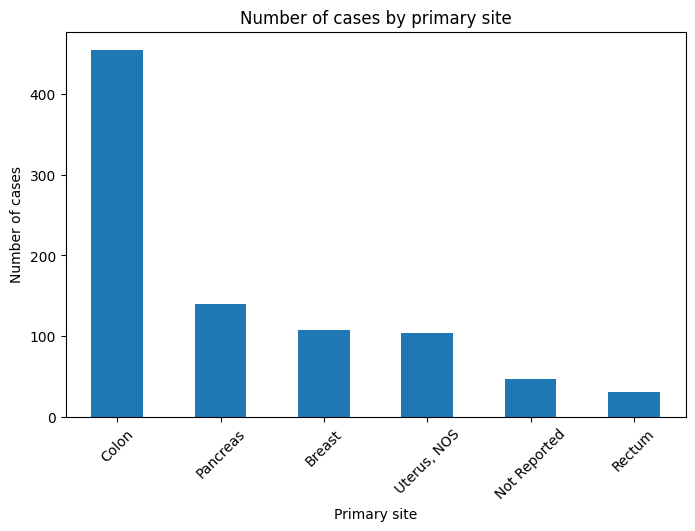

<Figure size 1000x700 with 0 Axes>

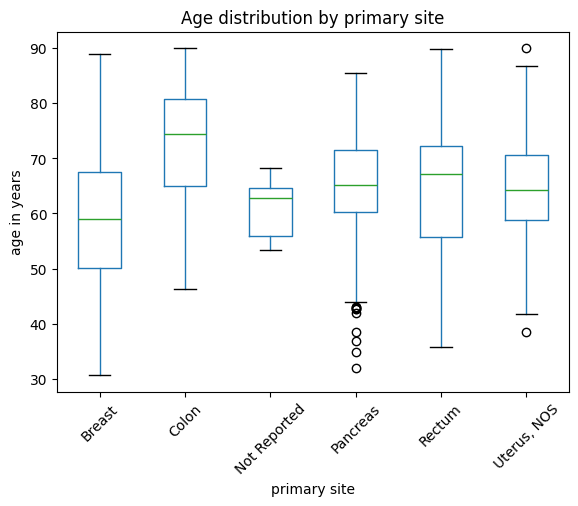

In [30]:
#viz number of cases by primary site
case_counts = merged_data['primary_site'].value_counts()
plt.figure(figsize=(8, 5))
case_counts.plot(kind='bar')
plt.title('Number of cases by primary site')
plt.xlabel('Primary site')
plt.ylabel('Number of cases')
plt.xticks(rotation=45)
plt.show()

#quick viz to see age distribution by cancer type
plt.figure(figsize=(10, 7))
merged_data.boxplot(column='age_years', by='primary_site', grid=False)
plt.title('Age distribution by primary site')
plt.suptitle('')
plt.xlabel('primary site')
plt.ylabel('age in years')
plt.xticks(rotation=45)
plt.show()


In [9]:

#how many rows with NaNs?
print(f"rows with NaNs: {merged_data.isna().any(axis=1).sum()}")
print(f"total rows: {len(merged_data)} ")

rows with NaNs: 854
total rows: 884 


In [13]:
#how many columns have NaNs in days_to_death?
print(f"rows with NaNs in days_to_death: {merged_data['days_to_death'].isna().sum()}")

rows with NaNs in days_to_death: 724


So most rows have at least one NaN...will need to subset first, then remove NaNs- some studies didn't collect certain data, so we may need to ony use particular study combos if looking at particular features
May need to come back and clean in different ways, but can create some cleaned up subsets at least for initial testing and EDA visualizations. 


In [ ]:
#create a subset of all records that have alcohol_history,
alcohol_subset = merged_data[merged_data['alcohol_history'].notna()]
print(f"rows with alcohol history: {len(alcohol_subset)}")
#print(alcohol_subset.head())

#create a subset of all records that have smoking history
smoking_subset = merged_data[merged_data['tobacco_smoking_status'].notna()]
print(f"rows with smoking history: {len(smoking_subset)}")
#print(smoking_subset.head())

#create a subset of all records that have days_to_death info
death_days_subset = merged_data[merged_data['days_to_death'].notna()]
print(f"rows with days_to_death info: {len(death_days_subset)}")
#print(death_days_subset.head())
#how many death_days records are also in the alcohol history subset?
death_and_alcohol = death_days_subset[death_days_subset['alcohol_history'].notna()]
print(f"rows with both days_to_death and alcohol history: {len(death_and_alcohol)}")
#print(death_and_alcohol.head())



rows with alcohol history: 255
rows with smoking history: 255
rows with days_to_death info: 160
rows with both days_to_death and alcohol history: 127


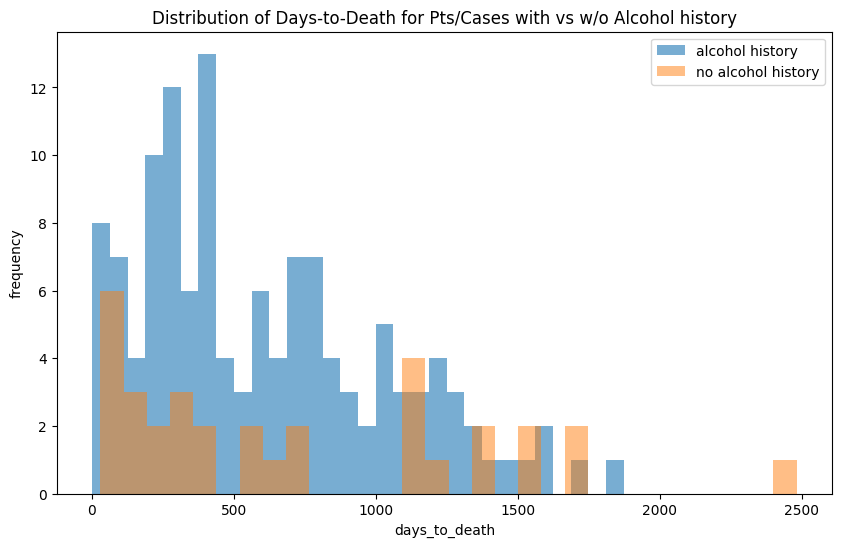

mean days_to_death - alcohol history: 606.5905511811023
mean days_to_death- no alcohol history: 721.6363636363636


In [34]:
#viz for days to death for alc history vs no alc history
plt.figure(figsize=(10,6))
plt.hist(death_and_alcohol['days_to_death'], bins=30, alpha=0.6, label='alcohol history')
plt.hist(death_days_subset[death_days_subset['alcohol_history'].isna()]['days_to_death'], bins=30, alpha=0.5, label='no alcohol history')
plt.xlabel('days_to_death')
plt.ylabel('frequency')
plt.title('Distribution of Days-to-Death for Pts/Cases with vs w/o Alcohol history')
plt.legend()
plt.show()

avg_death_with_alcohol = death_and_alcohol['days_to_death'].mean()
avg_death_no_alcohol = death_days_subset[death_days_subset['alcohol_history'].isna()]['days_to_death'].mean()
print(f"mean days_to_death - alcohol history: {avg_death_with_alcohol}")
print(f"mean days_to_death- no alcohol history: {avg_death_no_alcohol}")

In [36]:
#for each subset, drop columns that have a lot of missing data ie. for the alcohol history subset, drop the smoking history columns since most of those are missing; for the smoking history subset, drop the alcohol history columns; for the days_to_death subset, drop both alcohol and smoking history since those have a lot of missing data.
smoking_clean = smoking_subset.drop(columns=['alcohol_history', 'days_to_death'])
alcohol_clean = alcohol_subset.drop(columns=['tobacco_smoking_status', 'years_smoked', 'pack_years_smoked', 'days_to_death'])
death_days_clean = death_days_subset.drop(columns=['years_smoked', 'pack_years_smoked'])

#how many NAs are left in the cleaned subsets?
print(f"alcohol clean - rows with NaNs: {alcohol_clean.isna().any(axis=1).sum()}, total rows: {len(alcohol_clean)}")
print(f"smoking clean - rows with NaNs: {smoking_clean.isna().any(axis=1).sum()}, total rows: {len(smoking_clean)}")
print(f"death days clean - rows with NaNs: {death_days_clean.isna().any(axis=1).sum()}, total rows: {len(death_days_clean)}")

#drop rows with NAs from the alcohol clean and death_days clean since we'll still have a cgood amount of data left

alcohol_clean = alcohol_clean.dropna()
death_days_clean = death_days_clean.dropna()

alcohol clean - rows with NaNs: 7, total rows: 255
smoking clean - rows with NaNs: 201, total rows: 255
death days clean - rows with NaNs: 33, total rows: 160


In [37]:
#write out the clean datasets as csvs
alcohol_clean.to_csv('pdc_alcohol_clean.csv', index=False)
smoking_clean.to_csv('pdc_smoking_clean.csv', index=False)
death_days_clean.to_csv('pdc_death_days_clean.csv', index=False)

